# Tutorial on time of arrival estimation under jitter noise

## Scenario Description

My project requires precise estimation of time delay, or time of arrival (TOA), to calculate bearing angles using microelectrode arrays (MEAs). Because the electrodes are arranged in an array, each electrode should theoretically observe a delayed version of the same source signal. However, thermal noise at the receiver introduces random jitter, which perturbs the measured arrival times. This timing jitter reduces the accuracy of time-delay estimation.



## Introduction

Time of Arrival (TOA) estimation is a fundamental problem in localization. It involves determining the precise moment a signal, or a characteristic event within a signal, arrives at a sensor or detector. However, signals are often corrupted by various forms of uncertainty, collectively known as **jitter**. Jitter can be random or deterministic deviations in the timing of events from their ideal or expected instances. These timing variations can significantly degrade the accuracy of TOA estimates and, consequently, the performance of systems that rely on them.

This tutorial explores the concepts of correlation, its application in TOA estimation, and how **random** jitter influences this process. We will delve into the mathematical foundations and analyze the effects of applying cross-correlation for TOA estimation under random jitter.

### Types of Jitter: Deterministic and Random

Timing jitter for signal processing can be classified into 2 main categories based on its statistical properties and underlying causes. This document primarily focuses on random jitter.



#### 1. Deterministic Jitter (DJ)

Deterministic jitter can be caused by crosstalk interference, 50/60 Hz power supply noise, and multipath. It is characterized as a signal that is bounded, predictable, and may be either periodic or aperiodic. Periodic jitter is easily visible in frequency domain.

#### 2. Random Jitter (RJ)

Random jitter is primarily caused by thermal noise. It is characterized as a signal contaminated by an unbounded probabilistic distribution - typically a gaussian distribution.

### Other causes of jitter
Below are other potential causes of jitter, under the lens of timing applications for surgically placed brain micro electrode arrays (MEA). However, these will not be expanded upon for this tutorial. We believe that interference from other signals would be the main core possible effects on jitter to investigate for brain signals.


#### 1. Interference / Crosstalk

Different propagating signals (other brain activity, artifacts) can affect array electrodes differently. Unlike thermal noise, interference is structured and may have spatial coherence.

Potential mitigation techniques include

**MVDR (Minimum Variance Distortionless Response):**
- Adaptive beamforming technique that attempts to minimize output variance while maintaining unity gain in the direction of interest
- Requires knowledge or estimation of the signal direction and interference/noise covariance

**MUSIC (Multiple Signal Classification):**
- Uses eigendecomposition to separate signal and noise subspaces
- Can estimate direction of arrival for multiple signals
- Requires multiple snapshots and assumptions about the number of signal sources

#### 2. Multipath Propagation

Multipath refers to the phenomenon where the transmitted signal reaches the receiver via multiple paths due to reflections, creating multiple delayed and attenuated copies of the signal.

#### 3. Synchronization Errors

Sampling oscillators between electrode channels must be synchronized to align receiver timing with transmitter. Imperfect estimation leads to residual timing errors. However, for multiple electrode systems, we can assume electrode channels are built to share one oscillator.

#### 4. Oscillator Instability

Clocks in signal processing systems can drift over time. However, as we should assume the electrode system shares one oscillator, they all receive the same drift. For many position finding frameworks, the exact arrival time is not required and only the relative arrival time must be accurate.

#### 5. ADC Aperture Jitter

Analog-to-Digital Converters can sample at slightly incorrect times due to aperture jitter however, ADC jitter is primarily significant for high-frequency signals or high sampling rate systems. Electrode collection systems rarely go beyond 2 KHz, as much of the signals carry information at lower frequencies.

---

#### Side Notes

As electrodes degrade, their impedance tends to increase, potentially creating a frequency-dependent filtering effect. This degradation may disproportionately attenuate high-frequency signal components compared to low-frequency ones. It's worth investigating whether electrode aging can affect detection performance.



## Random Jitter and Correlation

Before describing how to detect and estimate jitter in signals, we first establish the theoretical foundations underlying these ideas and techniques. In the following sections, we show that correlation functions provide the primary framework for signal detection and delay estimation.



### What Is Correlation?

Correlation measures the similarity between two signals as a function of time lag. It quantifies how much one signal resembles another (or itself) when shifted by a delay $\tau$.

For continuous-time signals $r(t)$ and $s(t)$, the cross-correlation function is:

$$
R_{rs}(\tau) = \int_{-\infty}^{\infty} r(t) s^*(t - \tau) \, dt
$$

For discrete-time signals (sampled data):

$$
R_{rs}[m] = \sum_{n=-\infty}^{\infty} r[n] s^*[n - m]
$$

where $s^*$ denotes the complex conjugate (for real signals, $s^* = s$) Moving fowards, we assume this signal is **real** and **discrete**.

### Simplified description on how to conceptualize detection and estimation

The background in how correlation comes into play for time-delay estimation is defined under detection and estimation theory. The jargon can be confusing, so this section distills the important components into digestible and (hopefully) friendly analogies.

---

#### Detection Theory

Our goal is to **decide** whether a signal is **present** in noisy data. The model is defined by the **null hypothesis** ($H_0$: noise only) and the **alternative hypothesis** ($H_1$: signal + noise). We assume **data** comes from either $H_0$ or $H_1$. When we receive data, we measure its attributes with a **test statistic**, then compare that measurement to a **threshold** that balances Type I errors (false alarms) and Type II errors (misses). The test statistic should be defined to enable analysis and reasoning about the model's properties.

To give an analogy, imagine $H_0$ represents "short people" and $H_1$ represents "tall people." We visually estimate height in inches, so our **test statistic is eyeballing height**. We must choose a **threshold** height (say, 68 inches). If someone appears taller than 68 inches, we classify them as "tall" ($H_1$); otherwise, "short" ($H_0$). How we choose the threshold matters: if heights under $H_0$ and $H_1$ are Gaussian distributed with equal variance, and the populations are equal in size, placing the threshold exactly at the **midpoint between the two means** minimizes the overall probability of being wrong. This is called a **Bayes detector**. Alternatively, we could set the threshold to guarantee we rarely call a short person tall (control false alarms), even if it means missing some tall people. This is the **Neyman-Pearson** approach. Whether this model is true or useful must be validated through testing and analysis!

#### Estimation Theory

Our goal is to **determine** the **value** of an unknown parameter such as time delay. The **parameter** is the unknown quantity we want to estimate ($\tau$, $A$, etc.). We observe **data** that depends on this unknown parameter, then design an **estimator**—a function that produces an estimate $\hat{\tau}$ from the data. The quality of the estimate is measured by a **performance metric** (e.g., mean squared error, bias, variance). The estimator should be designed to optimize some criterion (e.g., maximum likelihood, minimum variance).

Continuing our height analogy, after quickly eyeballing whether someone is tall or short (detection), suppose we want to measure their **exact height**. We have 3 people measure a person's height with tape measurers and carefully measure from the ground to the top of their head. The true height $h_0$ is unknown to us beforehand. Each person gives us a reading $\hat{h}$, which is our **estimate** of the true height. In an ideal world, $\hat{h} = h_0$, but measurement errors introduce uncertainty—maybe the person shifts slightly, the tape isn't perfectly vertical, or we misread the markings. Our estimator quality depends on whether we're systematically too high or too low (bias), how much our measurements vary if we repeat them (variance), and the fundamental limit on accuracy for our measurement device (analogous to the Cramér-Rao bound). The maximum likelihood estimator would be the measurement procedure that, given our model of measurement errors, is most likely to have produced the data we observe.

#### Detection + Estimation

In practice, these often go together. First, **detection** and then **estimation**. For time delay estimation in signal processing, you correlate the received signal with a template and compare to a threshold to decide if signal is present. If there are no known templates, you try to detect a different feature of the signal. If detected, you find where the correlation peaked to estimate the delay.



### Threshold Peak Detection

Detection of signal in AWGN is a well-known derivation. I have drastically simplified the below relying on existing derivations.

We define two hypothesis tests, where:

- $H_0: r[n] = w[n]$ (noise only)
- $H_1: r[n] = s[n] + w[n]$ (signal + noise)

With the assumptions:
- $w[n] \sim \mathcal{N}(0, \sigma^2)$ i.i.d. over n
- $s[n]$ is **known**, deterministic

For the above formulation, it is well known that the log-likelihood ratio is:

$$
\ln \Lambda(\mathbf{r}) = \frac{1}{\sigma^2}\sum_{n=0}^{N-1} r[n]s[n] - \frac{E_s}{2\sigma^2}
$$

and the false alarm rate and detection probability are:

$$
P_{FA} = P(T > \gamma \mid H_0)
$$


$$
\gamma = \sigma\sqrt{E_s} \cdot Q^{-1}(P_{FA})
$$

where $Q(x) = \frac{1}{\sqrt{2\pi}} \int_x^{\infty} e^{-u^2/2} du$ is the Q-function.

and the test statsitic is the correlation function with a template s[n], or a **matched filter**:

$$
T = \sum_{n=0}^{N-1} r[n]s[n]
$$

---
For the case where we don't know the amplitude of the signal, we define two hypothesis tests, where:

- $H_0: r[n] = w[n]$ (noise only)
- $H_1: r[n] = As[n] + w[n]$ (signal + noise)

Using the Generalized Likelihood Ratio Test (GLRT)

$$
T = (\sum_{n=0}^{N-1} r[n]s[n])^2
$$

Which defines an **energy detector**

## TODO expand this section further

---

#### Complete Detection Rule

**Correlation (test statistic):**
$$
T = \sum_{n=0}^{N-1} r[n]s[n]
$$

**Threshold:**
$$
\gamma = \sigma\sqrt{E_s} \cdot Q^{-1}(P_{FA})
$$

**Decision:**
$$
T \gtrless \gamma \implies \begin{cases}
H_1 & \text{(signal present)} \\
H_0 & \text{(noise only)}
\end{cases}
$$

This derivation establishes that **correlation + threshold is the Neyman-Pearson optimal detector** for known signal in AWGN and detection is associated with the SNR.

#### Direct reference:
https://www.amazon.com/Introduction-Detection-Estimation-Electrical-Engineering/dp/0387941738

#### Possible references specific to detecting waveforms under interference and timing offset:
https://ieeexplore.ieee.org/document/1545871


### Maximum Likelihood Time Delay Estimation

Given that our noise is thermal noise, we can construct the maximum likelihood estimator for estimating time delay. Below, we define the received signal as:

**Received signal:**
$$
r[n] = s[n - \tau] + w[n]
$$

**Noise:**
$$
w[n] \sim \mathcal{N}(0, \sigma^2)
$$

where $w[n]$ is white Gaussian noise.

For i.i.d gaussian noise, it is well known that the ML estimator minimizes the squared error between the received signal and the original:

$$
\hat{\tau}_{ML} = \arg\min_{\tau} \sum_{n} \left[ r[n] - s[n - \tau] \right]^2
$$

For those who read my LS-RLS tutorial, you might notice that this has a similar for as batch least squares. However, it's important to note that the parameter to estimate $\tau$ is **nonlinearly** related in the equation to $s[n]$. Therefore, we cannot simply apply the linear LS solution of the psuedo-inverse.

However, rather than solve this iteratively using nonlinear LS solution methods, we can expanding the squared term:

$$
\sum_{n} \left[ r[n] - s[n - \tau] \right]^2 = \sum_{n} r^2[n] - 2\sum_{n} r[n] \, s[n - \tau] + \sum_{n} s^2[n - \tau]
$$

Given this expansion, we note the follow observations

- $\sum_{n} r^2[n]$: is independent of $\tau$
- $\sum_{n} s^2[n - \tau] = E_s$: is the signal energy, which is a constant
- $-2\sum_{n} r[n] \, s[n - \tau]$: depends on $\tau$

Therefore, minimizing the squared error is equivalent to **maximizing the cross-correlation**:

$$
\boxed{\hat{\tau}_{ML} = \arg\max_{\tau} \sum_{n} r[n] \, s[n - \tau]}
$$

$$
\boxed{\hat{\tau}_{ML} = \arg\max_{\tau} R_{rs}(\tau)}
$$

This is the **matched filter** operation: $s[n]$ acts as the filter matched to the received noisy signal $r[n]$, and the delay $\tau$ that maximizes the output is the ML estimate.

---
## TODO expand this section further
For the case where we don't know the amplitude of the signal...



### Maximum Likelihood Cross Channel Time delay estimation ( Incomplete)

Explanation of the General cross correlation and GCC-PHAT algorithm
https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=1162830

In short, there exists MLE and analysis for cross-channel correlation, which I will look into later, resulting in the MLE form finding time delay as cross correlation:

$$
\boxed{\hat{\tau}_{ML} = \arg\max_{\tau} \sum_{n} r_1[n] \, r_2[n - \tau]}
$$




## Signal characteristics that affect correlation under AWGN


### Auto-Correlation: An important signal analysis tool

Auto-correlation correlates a signal with a delayed version of itself:

$$
R_{ss}[\tau] = \sum_{n=-\infty}^{\infty} s[n] s[n - \tau]
$$

The auto-correlation of s[n] represents the ideal correlation function. This could be useful in practice for analysis as certain signals may contain multiple but smaller peaks, which under noise, can become false positive detections.

Waveform design in communications reguarlary take advantage of wide-band pulses (large frequency content and short pulse duration) signals to create a single sharp peak for position.

As you will see later, the signal of interest will have theoretical properties that relatively fit this criteria.

### Fisher Information for Time Delay Estimation (Discrete-Time)


The fisher information for a discrete signal in AWGN is well known and defined as:

$$I(\tau) = \frac{1}{\sigma^2} \sum_{n=0}^{N-1} \left(\frac{\partial s[n-\tau]}{\partial \tau}\right)^2$$

Using the frequency-domain relationship and Parseval's theorem and from the definition of the mean-square bandwidth:

$$I(\tau) = \frac{1}{\sigma^2} \cdot \frac{1}{2\pi} \int_{-\pi}^{\pi} \omega^2 |S(\omega)|^2 d\omega$$

$$\beta^2 := \frac{\int_{-\pi}^{\pi} \omega^2 |S(\omega)|^2 d\omega}{2\pi E_s}$$

where $E_s = \sum_{n} |s[n]|^2$ is the signal energy.

We can obtain the fisher information in terms of bandwidth

$$I(\tau) = \beta^2 \cdot \frac{E_s}{\sigma^2} = \beta^2 \cdot \text{SNR}$$

---

The cramér-rao lower bound (CRLB) is then

$$\text{var}(\hat{\tau}) \geq \frac{1}{I(\tau)} = \frac{1}{\beta^2 \cdot \text{SNR}} = \frac{\sigma^2}{\beta^2 E_s}$$

In general, a signal with a **wider bandwidth** (larger $\beta^2$) results in lower variance results in **better** time delay estimation **accuracy**.


## Applied bottom-line considerations for Noise-Induced Jitter

In short, we defined the importance of:
- The **correlation function** for our task of detecting a signal and estimating its time-delay.
- Why a **threshold** over the correlation function or the signal energy is useful for detecting a signal in AWGN.
- The **relationship the bandwidth or correlation width** that the signal of interest has with our ability to detect and estimate its time-delay.

On the below code, we analyze these relationships first with some dummy waveforms.

TODO: Later we may do this analysis on some templates of the interictal epileptic discharges (IED). We cannot apply this to real IED data in this tutorial due to privacy concerns and agreements made from those who have given me access.


### Python helper code

Below are helper codes like plotting functionality, noise calculation, 95% BW definition, and CRLB calculation

<font color="blue">In document, certain code is not included</font>

In [ ]:
# @title
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

def plot_time_domain_signals(time, signals, titles, fs):
    """
    Plots multiple signals in the time domain as subplots.

    Args:
        time (np.ndarray): Time vector.
        signals (list of np.ndarray): List of signal arrays to plot.
        titles (list of str): List of titles for each subplot.
        fs (int): Sampling frequency for x-axis formatting.
    """
    num_plots = len(signals)
    fig, axes = plt.subplots(num_plots, 1, figsize=(12, 2 * num_plots), sharex=True)
    if num_plots == 1: # Handle single subplot case
        axes = [axes]

    for i, (signal, title) in enumerate(zip(signals, titles)):
        axes[i].plot(time * 1000, signal) # Convert time to ms
        axes[i].set_title(title)
        axes[i].set_ylabel('Amplitude')
        axes[i].grid(True)

    axes[-1].set_xlabel('Time (ms)')
    plt.tight_layout()
    plt.show()
from scipy.signal import spectrogram

def plot_waterfall_psd(time, signals, titles, fs):
    """
    Plots the Power Spectral Density (PSD) as a waterfall plot for multiple signals.

    Args:
        time (np.ndarray): Time vector.
        signals (list of np.ndarray): List of signal arrays to plot.
        titles (list of str): List of titles for each subplot.
        fs (int): Sampling frequency.
    """
    num_plots = len(signals)
    fig, axes = plt.subplots(1, num_plots, figsize=(5 * num_plots, 6), sharex=True) # Changed to 1 row, num_plots columns
    if num_plots == 1:
        axes = [axes]

    nperseg = min(256, len(time) // 8) # Number of samples per segment for spectrogram
    noverlap = nperseg // 2 # Overlap between segments

    all_Sxx_db = []
    spectrogram_data = []

    # First pass: calculate all spectrograms and collect Sxx values
    for signal in signals:
        f, t_spec, Sxx = spectrogram(signal, fs, nperseg=nperseg, noverlap=noverlap)
        Sxx_db = 10 * np.log10(Sxx + 1e-10) # Add a small epsilon to avoid log(0) and the RuntimeWarning
        all_Sxx_db.append(Sxx_db)
        spectrogram_data.append((f, t_spec, Sxx_db))

    # Determine global min and max for consistent colormap
    global_vmin = np.min([np.min(s) for s in all_Sxx_db])
    global_vmax = np.max([np.max(s) for s in all_Sxx_db])

    # Second pass: plot with consistent colormap
    for i, (f, t_spec, Sxx_db) in enumerate(spectrogram_data):
        title = titles[i]
        im = axes[i].pcolormesh(t_spec * 1000, f / 1000, Sxx_db, shading='gouraud', cmap='viridis', vmin=global_vmin, vmax=global_vmax)
        axes[i].set_title(title)
        axes[i].set_ylabel('Frequency (kHz)')
        axes[i].set_ylim([0, fs / 2000]) # Display up to fs/2 in kHz
        axes[i].grid(True, which='both', linestyle=':', alpha=0.6)
        fig.colorbar(im, ax=axes[i], format="%0.1f dB", label='Power/Frequency (dB/Hz)')

    axes[-1].set_xlabel('Time (ms)')
    plt.tight_layout()
    plt.show()


In [ ]:
import scipy.signal
import numpy as np # Import numpy for trapezoid

def calculate_95_percent_power_bandwidth(signal, fs):
    """
    Calculates the 95% power bandwidth of a signal.

    Args:
        signal (np.ndarray): The input signal.
        fs (int): The sampling frequency (Hz).

    Returns:
        float: The 95% power bandwidth in Hz.
    """
    # Compute the power spectral density (PSD) using Welch's method
    # nperseg chosen to be consistent with spectrogram or a reasonable default
    nperseg = min(256, len(signal) // 8)
    frequencies, psd = scipy.signal.welch(signal, fs=fs, nperseg=nperseg)

    # Calculate the total power
    total_power = np.trapezoid(psd, frequencies) # Updated to np.trapezoid

    # Find the power threshold for 95% of total power
    target_power = 0.95 * total_power

    # Find the cumulative power
    cumulative_power = np.cumsum(psd * np.diff(frequencies, append=0))

    # Find the frequency range where 95% of the power is concentrated
    # This is a simplified approach, often the bandwidth is defined relative to peak.
    # For 95% power, we'll find the lowest and highest frequency that enclose this.

    # Find the index where cumulative power first exceeds 0.025 * total_power
    idx_low = np.where(cumulative_power >= 0.025 * total_power)[0][0]
    # Find the index where cumulative power first exceeds 0.975 * total_power
    idx_high = np.where(cumulative_power >= 0.975 * total_power)[0][0]

    bandwidth = frequencies[idx_high] - frequencies[idx_low]

    return bandwidth


In [ ]:
import numpy as np

def calculate_crlb_rmse(signal, fs, snr_dbs):
    """
    Calculates the Cramér-Rao Lower Bound (RMSE) for time delay estimation.

    Args:
        signal: Clean signal template
        fs: Sampling frequency (Hz)
        snr_dbs: List of SNR values in dB

    Returns:
        CRLB RMSE values in milliseconds for each SNR
    """
    N = len(signal)
    energy = np.sum(signal**2)

    if energy == 0:
        return np.full(len(snr_dbs), np.nan)

    # Frequency domain representation
    S = np.fft.fft(signal)
    omega = 2 * np.pi * np.fft.fftfreq(N, 1/fs)

    # Fisher Information term (independent of noise)
    # I(tau) = (1/sigma^2) * (fs/N) * sum(omega^2 * |S|^2)
    # Below is missing variance - included later per SNR.
    fisher_info_term = (fs / N) * np.sum(omega**2 * np.abs(S)**2)

    if fisher_info_term == 0:
        return np.full(len(snr_dbs), np.nan)

    # Calculate CRLB for each SNR
    crlb_rmse_ms = []
    for snr_db in snr_dbs:
        snr_linear = 10**(snr_db / 10)
        noise_var = energy / snr_linear

        # Fisher Information: I(tau) = fisher_info_term / sigma^2
        fisher_info = fisher_info_term / noise_var

        # CRLB variance = 1 / I(tau)
        crlb_var = 1 / fisher_info

        crlb_rmse_ms.append(np.sqrt(crlb_var) * 1000)  # Convert to ms

    return np.array(crlb_rmse_ms)

In [ ]:
# @title
import numpy as np
from scipy.stats import rayleigh

def generate_noisy_signals(
    fs=2000, T=0.3, delay_t=0.005,
    pulse_amplitude=1.0, pulse_center_time=0.1, pulse_spread=0.04,
    snr_db=10
):
    """
    Generates an asymmetric Rayleigh-like pulse, AWGN, and delayed noisy signals.

    Args:
        fs (int): Sampling frequency (Hz).
        T (float): Total simulation time (seconds).
        delay_t (float): Delay for the second receiver signal (seconds).
        pulse_amplitude (float): Amplitude of the Rayleigh-like pulse.
        pulse_center_time (float): Time at which the pulse roughly peaks.
        pulse_spread (float): Controls the width/spread of the pulse (smaller = wider bandwidth).
        snr_db (int): Signal-to-noise ratio in dB.

    Returns:
        tuple: (time_vector, original_signal, noise_signal,
                receiver1_signal, receiver2_signal)
    """
    num_samples = int(fs * T)
    t = np.linspace(0, T, num_samples, endpoint=False)

    # Generate the asymmetric Rayleigh-like pulse (s_n)
    s_n_unscaled = rayleigh.pdf(t, loc=pulse_center_time - pulse_spread, scale=pulse_spread)
    s_n_unscaled = np.nan_to_num(s_n_unscaled) # Replace potential NaN/inf with 0
    s_n = pulse_amplitude * s_n_unscaled / (np.max(s_n_unscaled) + 1e-9)

    # Additive White Gaussian Noise (AWGN) parameters
    signal_power = np.mean(s_n**2)
    if signal_power == 0:
        noise_power = (10**(-snr_db / 10)) * (pulse_amplitude**2 / 2)
    else:
        noise_power = signal_power / (10**(snr_db / 10))

    noise_std_dev = np.sqrt(noise_power)
    noise = noise_std_dev * np.random.randn(num_samples) # Noise for receiver 1

    # Receiver 1 signal (s_n + noise)
    r1_n = s_n + noise

    # Receiver 2 signal (delayed s_n + independent noise)
    delay_samples = int(delay_t * fs)
    s_n_delayed = np.roll(s_n, delay_samples)
    s_n_delayed[:delay_samples] = 0 # Remove wrapped-around portion

    noise2 = noise_std_dev * np.random.randn(num_samples) # Independent noise for receiver 2
    r2_n = s_n_delayed + noise2

    return t, s_n, noise, r1_n, r2_n



## Case Study: Correlation between channels to detect neurological signals and signatures that exist between channels

### Testing and matched filter analysis on skewed narrow vs wideband signals

In the math above, we perform analysis and derive our findings on the idea that correlation is performed with complete knowledge of the time delay. However, in the case that we don't know our time delay, we must also estimate that. I have not done that analysis, but our below code will be searching and calculating the error from the true time delay. Our analysis will talk briefly on when this issue affects our results.

#### Plotting and signal generator

To test our code, let's define a simple pulsed waveform and a waveform that will be affected by noise. We use an asymmetric pulse-like rayleigh distribution-like function that will be band-limited and to show a sort of timing offset. Another receiver, r2, will have the same AWGN channel and capture a delayed version with respect to another receiver.

In [ ]:
import numpy as np
from scipy.stats import rayleigh
from scipy.signal import convolve, windows

# Simulation parameters
fs = 2000  # Sampling frequency (Hz)
T = 0.3     # Total simulation time (seconds)
num_samples = int(fs * T)
delay_t = 0.005 # 5 ms delay in samples
t = np.linspace(0, T, num_samples, endpoint=False)

# Pulse parameters (for the asymmetric Rayleigh-like pulse)
pulse_amplitude = 1.0
pulse_center_time = 0.1 # Time at which the pulse roughly peaks
pulse_spread = 0.04 # Controls the width/spread of the pulse (smaller = wider bandwidth)
#pulse_spread = 0.0005 # Controls the width/spread of the pulse (smaller = wider bandwidth)

# Example usage of the new function
t, s_n, noise, r1_n, r2_n = generate_noisy_signals(
    fs=fs, T=T, delay_t=delay_t,
    pulse_amplitude=pulse_amplitude, pulse_center_time=pulse_center_time, pulse_spread=pulse_spread,
    snr_db=10
)



In [ ]:
bw_n = calculate_95_percent_power_bandwidth(s_n, fs)
print(f"95% Power Bandwidth for narrowband signal (s_n): {bw_n:.2f} Hz")


95% Power Bandwidth for narrowband signal (s_n): 53.33 Hz


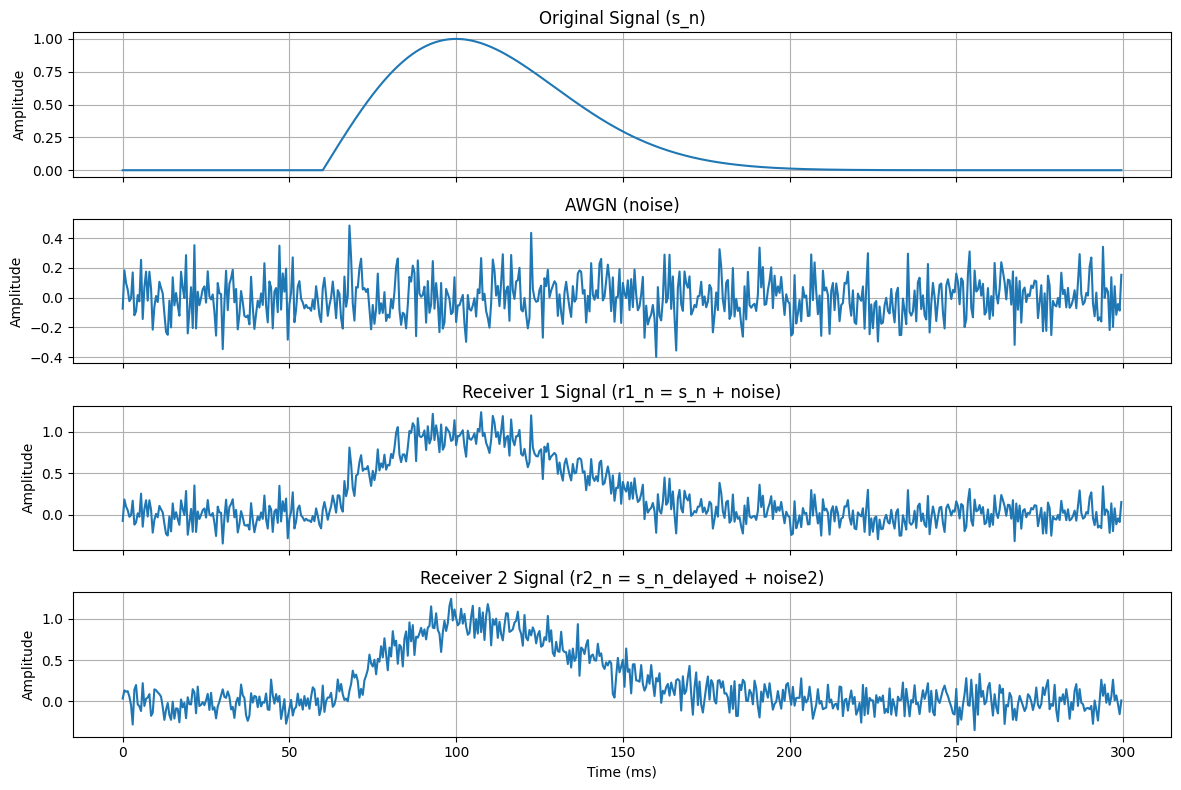

In [ ]:

# Call the plotting function for time domain
plot_time_domain_signals(
    t,
    [s_n, noise, r1_n, r2_n],
    ['Original Signal (s_n)', 'AWGN (noise)', 'Receiver 1 Signal (r1_n = s_n + noise)', 'Receiver 2 Signal (r2_n = s_n_delayed + noise2)']
    , fs
)


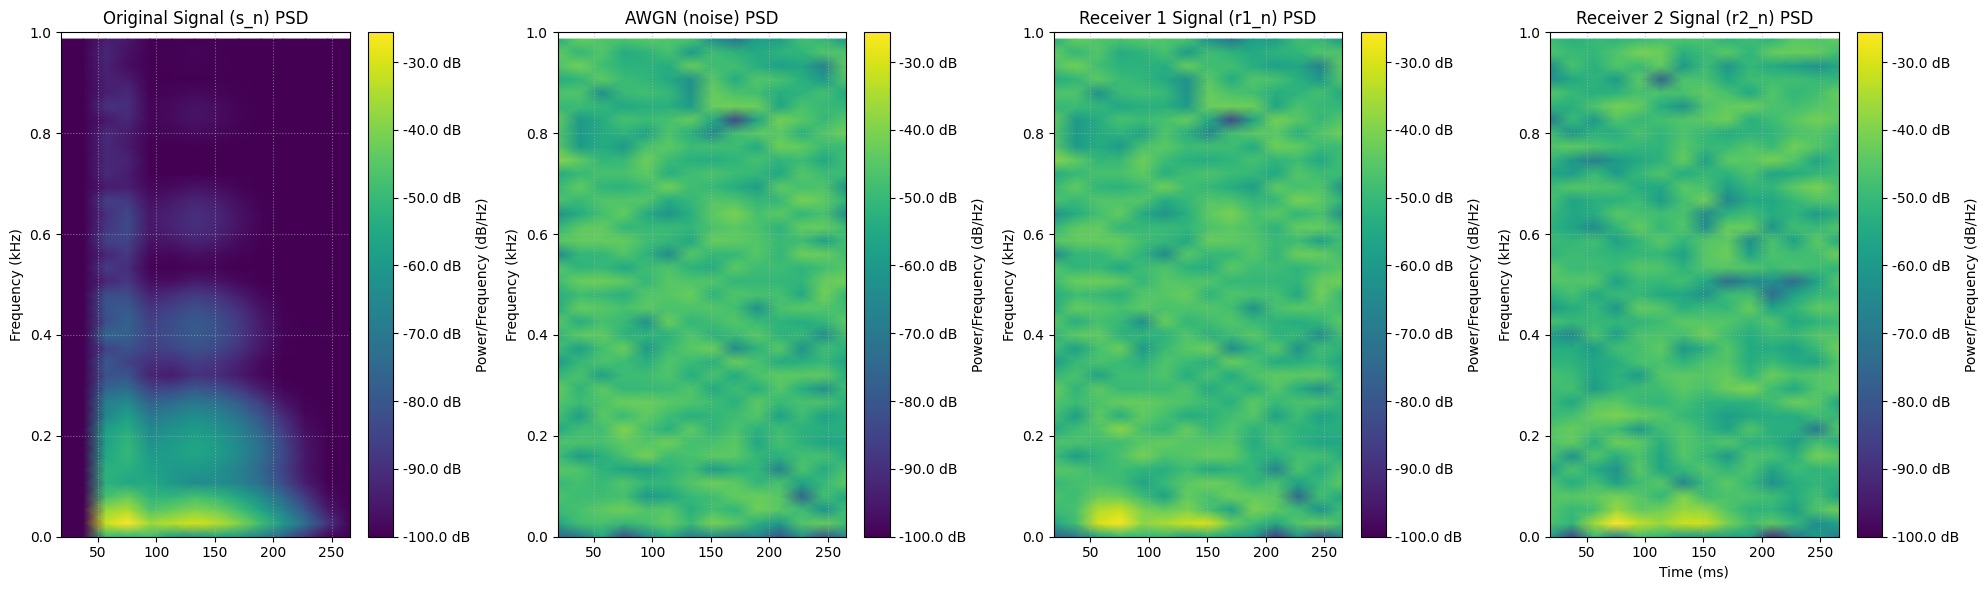

In [ ]:
# Call the plotting function for waterfall PSD
plot_waterfall_psd(
    t,
    [s_n, noise, r1_n, r2_n],
    ['Original Signal (s_n) PSD', 'AWGN (noise) PSD', 'Receiver 1 Signal (r1_n) PSD', 'Receiver 2 Signal (r2_n) PSD'],
    fs
)


In [ ]:
pulse_spread = 0.005 # Controls the width/spread of the pulse (smaller = wider bandwidth)

# Example usage of the new function
t, s_w, noise_w, r1_w, r2_w = generate_noisy_signals(
    fs=fs, T=T, delay_t=delay_t,
    pulse_amplitude=pulse_amplitude, pulse_center_time=pulse_center_time, pulse_spread=pulse_spread,
    snr_db=10
)

In [ ]:
bw_w = calculate_95_percent_power_bandwidth(s_w, fs)
print(f"95% Power Bandwidth for wideband signal (s_w): {bw_w:.2f} Hz")

95% Power Bandwidth for wideband signal (s_w): 80.00 Hz


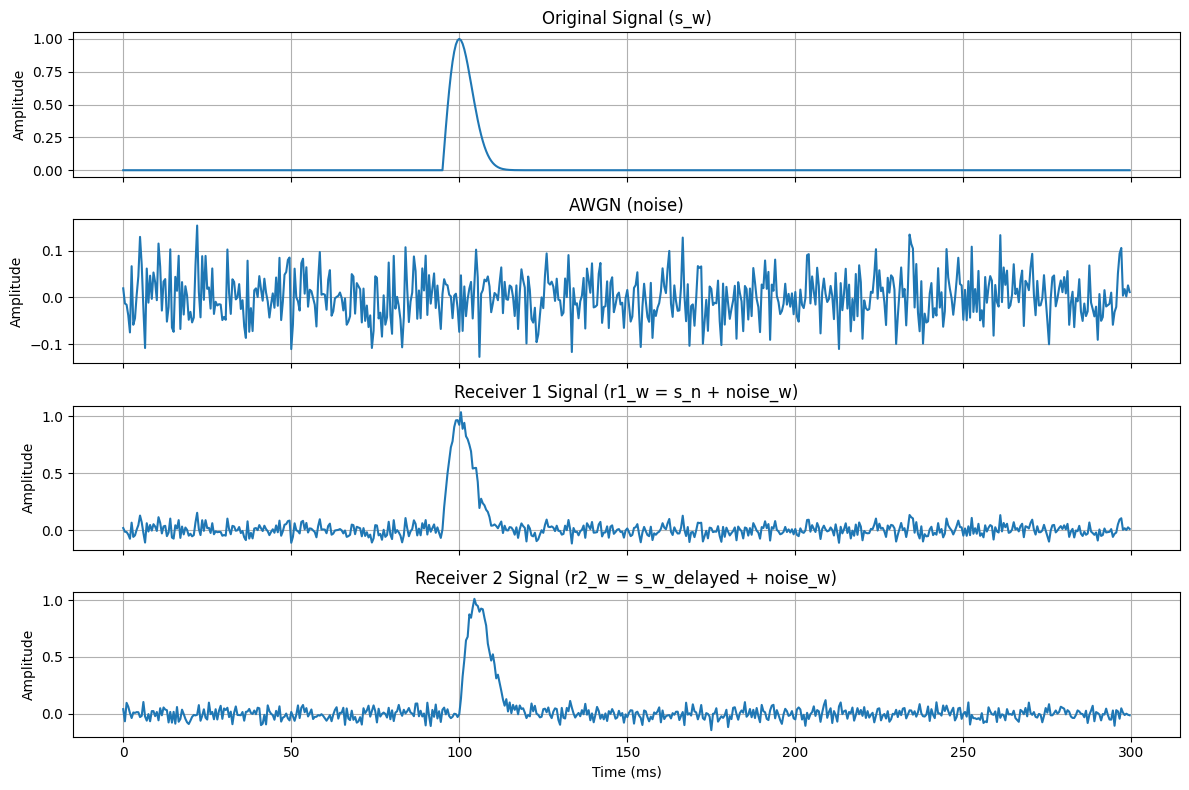

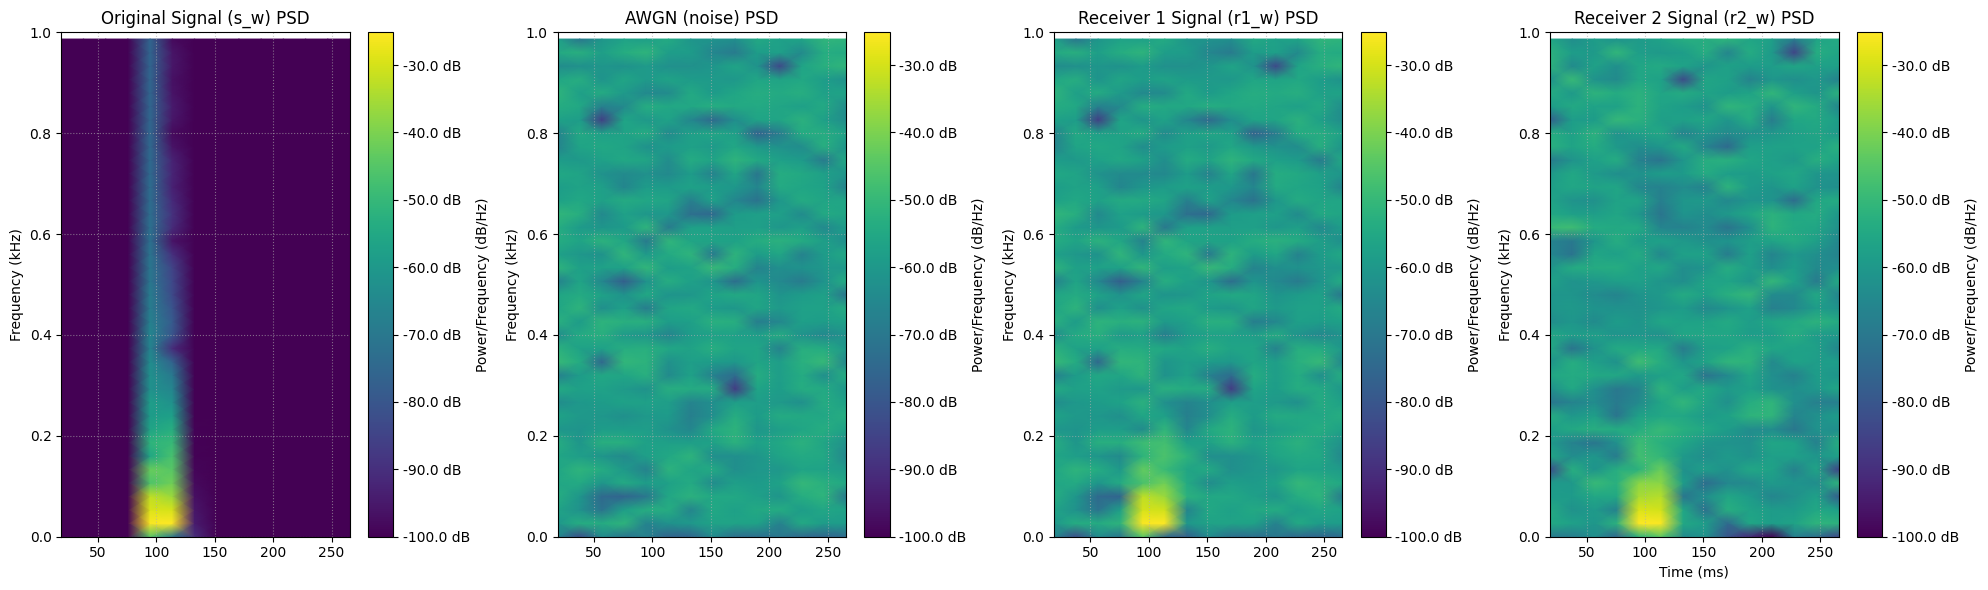

In [ ]:
# Call the plotting function for time domain
plot_time_domain_signals(
    t,
    [s_w, noise_w, r1_w, r2_w],
    ['Original Signal (s_w)', 'AWGN (noise)', 'Receiver 1 Signal (r1_w = s_n + noise_w)', 'Receiver 2 Signal (r2_w = s_w_delayed + noise_w)']
    , fs
)
plot_waterfall_psd(
    t,
    [s_w, noise_w, r1_w, r2_w],
    ['Original Signal (s_w) PSD', 'AWGN (noise) PSD', 'Receiver 1 Signal (r1_w) PSD', 'Receiver 2 Signal (r2_w) PSD'],
    fs
)

Okay now that we have defined our narrowband and wideband signal generators. We calculate the bandwidth as 95% of the signal power. We perform a correlation function and threshold, run a monte-carlo simulation on our accuracy of delay calculation.

#### Thresholding on Correlation Results

A threshold function is applied to the correlation function to detect it,
Before the correlation peak time-delay is estimated.

In [ ]:
def apply_threshold_to_correlation(correlation_function, threshold_factor=0.5):
    """
    Applies a threshold to the normalized correlation function.

    Args:
        correlation_function (np.ndarray): The cross-correlation function.
        threshold_factor (float): Factor of the peak correlation to use as threshold (0 to 1).

    Returns:
        tuple: (thresholded_correlation, threshold_value, peak_location_idx)
    """
    max_corr = np.max(correlation_function)
    threshold_value = threshold_factor * max_corr

    # Create a copy to avoid modifying the original array directly
    thresholded_correlation = np.copy(correlation_function)
    thresholded_correlation[thresholded_correlation < threshold_value] = 0

    peak_location_idx = np.argmax(correlation_function)

    return thresholded_correlation, threshold_value, peak_location_idx



#### Correlation Function for Delay Estimation

This section includes code that performs correlation between channels or between a template. For both cases, the delay is estimated by taking index of the sample with the maximum value.

In [ ]:
# @title
from scipy.signal import correlate

def estimate_delay_via_correlation(signal1, signal2, fs):
    """
    Estimates the time delay between two signals using cross-correlation.
    This is for correlating two *received* signals directly.

    Args:
        signal1 (np.ndarray): The first signal (e.g., reference signal).
        signal2 (np.ndarray): The second signal (e.g., delayed signal).
        fs (int): The sampling frequency (Hz).

    Returns:
        tuple: (estimated_delay_samples, estimated_delay_seconds,
                correlation_function, lags)
    """
    correlation = correlate(signal2, signal1, mode='full')
    lags = np.arange(-len(signal1) + 1, len(signal2))

    # Find the index of the maximum correlation
    delay_samples = lags[np.argmax(correlation)]
    estimated_delay_seconds = delay_samples / fs

    return delay_samples, estimated_delay_seconds, correlation, lags

def estimate_arrival_time_with_matched_filter(received_signal, template_signal, fs):
    """
    Estimates the arrival time of a signal in a received signal using a known template
    (matched filter approach).

    Args:
        received_signal (np.ndarray): The noisy received signal.
        template_signal (np.ndarray): The clean, known signal template.
        fs (int): The sampling frequency (Hz).

    Returns:
        float: The estimated arrival time in seconds relative to the start of the received signal.
               Returns None if template_signal is zero everywhere, to avoid division by zero.
    """
    # Normalize template signal to avoid issues with amplitude scaling
    if np.sum(template_signal**2) == 0: # Avoid division by zero if template is all zeros
        return None
    normalized_template = template_signal / np.sqrt(np.sum(template_signal**2))

    # Cross-correlate the received signal with the (flipped) template
    # correlate(a, v, mode='full') computes convolution(a, v[::-1], mode='full')
    # This is equivalent to correlation if v is the template.
    correlation_output = correlate(received_signal, normalized_template, mode='full')
    lags = np.arange(-len(received_signal) + 1, len(normalized_template))

    # The peak of the correlation indicates the lag where the template best matches the received signal.
    # The lag directly gives the arrival time relative to the start of the received signal.
    peak_idx = np.argmax(correlation_output)
    estimated_lag_samples = lags[peak_idx]
    estimated_arrival_time_seconds = estimated_lag_samples / fs

    return estimated_arrival_time_seconds


Narrowband Signal - Peak Correlation: 95.8792, Threshold Value: 47.9396
Narrowband Signal Estimated Delay (samples): 11
Narrowband Signal Estimated Delay (seconds): 0.0055 s
Narrowband Signal Estimated Delay (milliseconds): 5.50 ms

Wideband Signal - Peak Correlation: 11.9794, Threshold Value: 5.9897
Wideband Signal Estimated Delay (samples): 10
Wideband Signal Estimated Delay (seconds): 0.0050 s
Wideband Signal Estimated Delay (milliseconds): 5.00 ms


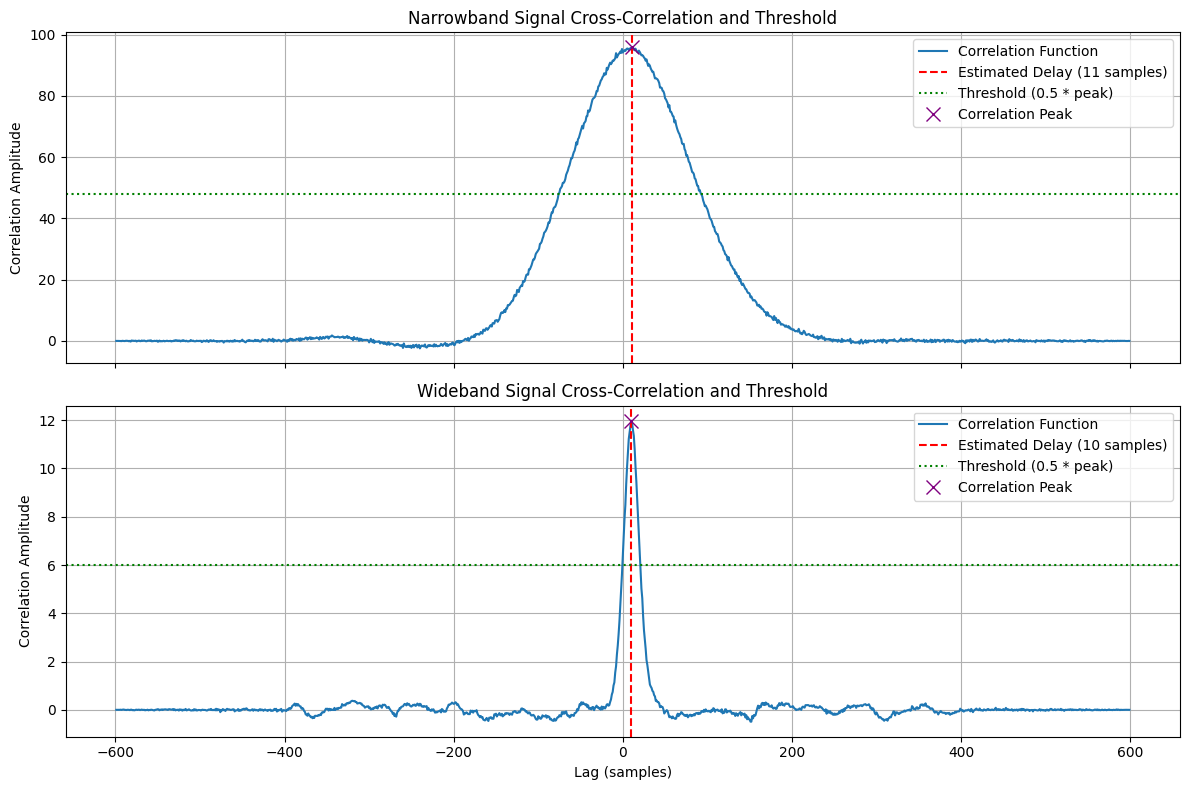

In [ ]:
# Calculate correlation functions and delays for narrowband signals
delay_samples_n, delay_seconds_n, corr_n, lags_n = estimate_delay_via_correlation(r1_n, r2_n, fs)

# Calculate correlation functions and delays for wideband signals
delay_samples_w, delay_seconds_w, corr_w, lags_w = estimate_delay_via_correlation(r1_w, r2_w, fs)

# Apply thresholding for narrowband signals
thresholded_corr_n, threshold_value_n, peak_idx_n = apply_threshold_to_correlation(corr_n, threshold_factor=0.5)
print(f"Narrowband Signal - Peak Correlation: {np.max(corr_n):.4f}, Threshold Value: {threshold_value_n:.4f}")
print(f"Narrowband Signal Estimated Delay (samples): {delay_samples_n}")
print(f"Narrowband Signal Estimated Delay (seconds): {delay_seconds_n:.4f} s")
print(f"Narrowband Signal Estimated Delay (milliseconds): {delay_seconds_n * 1000:.2f} ms\n")

# Apply thresholding for wideband signals
thresholded_corr_w, threshold_value_w, peak_idx_w = apply_threshold_to_correlation(corr_w, threshold_factor=0.5)
print(f"Wideband Signal - Peak Correlation: {np.max(corr_w):.4f}, Threshold Value: {threshold_value_w:.4f}")
print(f"Wideband Signal Estimated Delay (samples): {delay_samples_w}")
print(f"Wideband Signal Estimated Delay (seconds): {delay_seconds_w:.4f} s")
print(f"Wideband Signal Estimated Delay (milliseconds): {delay_seconds_w * 1000:.2f} ms")

# Plotting the correlation functions with thresholds
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Narrowband
axes[0].plot(lags_n, corr_n, label='Correlation Function')
axes[0].axvline(delay_samples_n, color='red', linestyle='--', label=f'Estimated Delay ({delay_samples_n} samples)')
axes[0].axhline(threshold_value_n, color='green', linestyle=':', label=f'Threshold (0.5 * peak)')
axes[0].plot(lags_n[peak_idx_n], np.max(corr_n), 'x', color='purple', markersize=10, label='Correlation Peak')
axes[0].set_title('Narrowband Signal Cross-Correlation and Threshold')
axes[0].set_ylabel('Correlation Amplitude')
axes[0].grid(True)
axes[0].legend()

# Wideband
axes[1].plot(lags_w, corr_w, label='Correlation Function')
axes[1].axvline(delay_samples_w, color='red', linestyle='--', label=f'Estimated Delay ({delay_samples_w} samples)')
axes[1].axhline(threshold_value_w, color='green', linestyle=':', label=f'Threshold (0.5 * peak)')
axes[1].plot(lags_w[peak_idx_w], np.max(corr_w), 'x', color='purple', markersize=10, label='Correlation Peak')
axes[1].set_title('Wideband Signal Cross-Correlation and Threshold')
axes[1].set_xlabel('Lag (samples)')
axes[1].set_ylabel('Correlation Amplitude')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

#### Correlation Plot at Low SNR (-5 dB) to Show Jitter Noise

To illustrate the impact of jitter noise, especially at low Signal-to-Noise Ratios, let's regenerate the narrowband signals with a -5 dB SNR and visualize their cross-correlation. This will demonstrate how the correlation peak becomes broader and less distinct, making accurate delay estimation more challenging due to the increased noise.

Low SNR (-5 dB) Narrowband Signal - Estimated Delay (samples): 17
Low SNR (-5 dB) Narrowband Signal - Estimated Delay (milliseconds): 8.50 ms


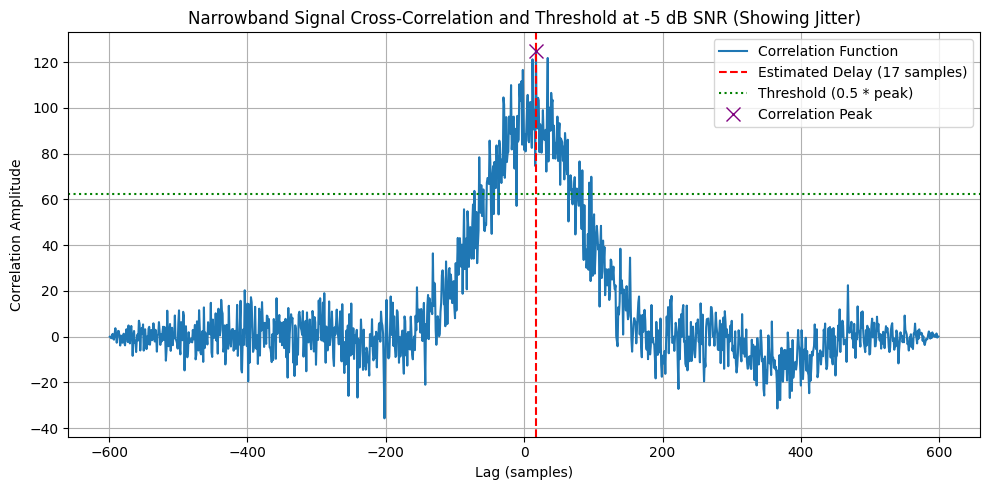

In [ ]:
low_snr_db = -5 # Example low SNR

# Generate narrowband signals at low SNR
t_low_snr, s_n_low_snr, noise_low_snr, r1_n_low_snr, r2_n_low_snr = generate_noisy_signals(
    fs=fs, T=T, delay_t=delay_t,
    pulse_amplitude=pulse_amplitude, pulse_center_time=pulse_center_time, pulse_spread=0.04,
    snr_db=low_snr_db
)

# Estimate delay for low SNR narrowband signals
delay_samples_low_snr, delay_seconds_low_snr, corr_low_snr, lags_low_snr = estimate_delay_via_correlation(r1_n_low_snr, r2_n_low_snr, fs)

# Apply thresholding for plotting
thresholded_corr_low_snr, threshold_value_low_snr, peak_idx_low_snr = apply_threshold_to_correlation(corr_low_snr, threshold_factor=0.5)

print(f"Low SNR ({low_snr_db} dB) Narrowband Signal - Estimated Delay (samples): {delay_samples_low_snr}")
print(f"Low SNR ({low_snr_db} dB) Narrowband Signal - Estimated Delay (milliseconds): {delay_seconds_low_snr * 1000:.2f} ms")

# Plotting the correlation function with threshold at low SNR
plt.figure(figsize=(10, 5))
plt.plot(lags_low_snr, corr_low_snr, label='Correlation Function')
plt.axvline(delay_samples_low_snr, color='red', linestyle='--', label=f'Estimated Delay ({delay_samples_low_snr} samples)')
plt.axhline(threshold_value_low_snr, color='green', linestyle=':', label=f'Threshold (0.5 * peak)')
plt.plot(lags_low_snr[peak_idx_low_snr], np.max(corr_low_snr), 'x', color='purple', markersize=10, label='Correlation Peak')
plt.title(f'Narrowband Signal Cross-Correlation and Threshold at {low_snr_db} dB SNR (Showing Jitter)')
plt.xlabel('Lag (samples)')
plt.ylabel('Correlation Amplitude')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
true_delay_s = delay_t # The true delay in seconds
error_from_truth_s = delay_seconds_low_snr - true_delay_s
print(f"True Delay (s): {true_delay_s:.4f}")
print(f"Estimated Delay (low SNR) (s): {delay_seconds_low_snr:.4f}")
print(f"Error from Truth (s): {error_from_truth_s:.4f}")
print(f"Error from Truth (ms): {error_from_truth_s * 1000:.2f} ms")

True Delay (s): 0.0050
Estimated Delay (low SNR) (s): 0.0085
Error from Truth (s): 0.0035
Error from Truth (ms): 3.50 ms


### Testing and correlation analysis on skewed narrow vs wideband signals

Correlation performance between two channels for when the signal is wideband vs narrowband - in the case where we do not have a matched filter.



#### Monte Carlo Simulation for Delay Estimation Accuracy

In [ ]:
# @title
import tqdm # For progress bar

def run_monte_carlo_simulation(num_runs, fs, T, true_delay_between_channels, pulse_amplitude, pulse_center_time, pulse_spread_list, snr_db_list, use_matched_filter=False):
    """
    Runs a Monte Carlo simulation to evaluate delay estimation accuracy for different pulse spreads and SNRs.
    Can run in either direct cross-correlation mode or matched filter mode.

    Args:
        num_runs (int): Number of simulation runs for each condition.
        fs (int): Sampling frequency (Hz).
        T (float): Total simulation time (seconds).
        true_delay_between_channels (float): True delay for the second receiver signal (seconds).
        pulse_amplitude (float): Amplitude of the Rayleigh-like pulse.
        pulse_center_time (float): Time at which the pulse roughly peaks.
        pulse_spread_list (list): List of pulse_spread values to test.
        snr_db_list (list): List of SNR values in dB to test.
        use_matched_filter (bool): If True, use a matched filter approach; else, direct cross-correlation of received signals.

    Returns:
        dict: A dictionary containing simulation results (estimated delays, errors).
    """
    results = {
        'true_delay': true_delay_between_channels,
        'fs': fs,
        'pulse_spreads': pulse_spread_list,
        'snrs': snr_db_list,
        'estimated_delays': {},
        'delay_errors': {}
    }

    simulation_type = "Matched Filter" if use_matched_filter else "Cross-Correlation"
    print(f"\nRunning Monte Carlo Simulation ({simulation_type} Mode)...")

    for pulse_spread in pulse_spread_list:
        results['estimated_delays'][f'spread_{pulse_spread}'] = {}
        results['delay_errors'][f'spread_{pulse_spread}'] = {}

        for snr_db in snr_db_list:
            estimated_delays_for_condition = []
            delay_errors_for_condition = []

            print(f"Running for Pulse Spread: {pulse_spread}, SNR: {snr_db} dB")
            for _ in tqdm.tqdm(range(num_runs), desc=f"  Spread {pulse_spread}, SNR {snr_db} dB"): # Corrected desc for tqdm
                # Generate new noisy signals for each run
                t_mc, s_mc, noise_mc, r1_mc, r2_mc = generate_noisy_signals(
                    fs=fs, T=T, delay_t=true_delay_between_channels,
                    pulse_amplitude=pulse_amplitude, pulse_center_time=pulse_center_time,
                    pulse_spread=pulse_spread, snr_db=snr_db
                )

                if use_matched_filter:
                    # Matched filter approach: estimate arrival time at each receiver using the clean signal template
                    arrival_time1 = estimate_arrival_time_with_matched_filter(r1_mc, s_mc, fs)
                    arrival_time2 = estimate_arrival_time_with_matched_filter(r2_mc, s_mc, fs)

                    if arrival_time1 is not None and arrival_time2 is not None:
                        estimated_delay_s = arrival_time2 - arrival_time1
                    else:
                        # If template is all zeros, unable to estimate, treat as max error
                        estimated_delay_s = np.nan # Or a large error value
                else:
                    # Direct cross-correlation of received signals
                    _, estimated_delay_s, _, _ = estimate_delay_via_correlation(r1_mc, r2_mc, fs)

                estimated_delays_for_condition.append(estimated_delay_s)
                # Handle potential NaN from matched filter for error calculation
                if not np.isnan(estimated_delay_s):
                    delay_errors_for_condition.append(estimated_delay_s - true_delay_between_channels)
                else:
                    delay_errors_for_condition.append(np.nan)

            results['estimated_delays'][f'spread_{pulse_spread}'][f'snr_{snr_db}'] = np.array(estimated_delays_for_condition)
            results['delay_errors'][f'spread_{pulse_spread}'][f'snr_{snr_db}'] = np.array(delay_errors_for_condition)

    return results

print("Monte Carlo Simulation function updated to include matched filter option.")

Monte Carlo Simulation function updated to include matched filter option.


In [ ]:
import pandas as pd

# --- Monte Carlo Simulation Parameters (from the previous cell) ---
num_monte_carlo_runs = 5000
monte_carlo_pulse_spreads = [0.04, 0.005] # Narrowband, Wideband
monte_carlo_snr_dbs = [-15, -10, -5, 0, 5, 10, 15, 20]

# Map pulse spread to bandwidths (from previous context)
bandwidth_map = {0.04: bw_n, 0.005: bw_w}

print(f"\nNarrowband Signal Pulse Spread: 0.04, 95% Power Bandwidth: {bandwidth_map[0.04]:.2f} Hz")
print(f"Wideband Signal Pulse Spread: 0.005, 95% Power Bandwidth: {bandwidth_map[0.005]:.2f} Hz\n")


# --- Run Monte Carlo Simulation: Cross-Correlation (No Matched Filter Template) ---
monte_carlo_results_no_mf = run_monte_carlo_simulation(
    num_monte_carlo_runs, fs, T, delay_t, pulse_amplitude, pulse_center_time,
    monte_carlo_pulse_spreads, monte_carlo_snr_dbs, use_matched_filter=False
)

results_summary_no_mf = []
for pulse_spread in monte_carlo_results_no_mf['pulse_spreads']:
    for snr_db in monte_carlo_results_no_mf['snrs']:
        errors = monte_carlo_results_no_mf['delay_errors'][f'spread_{pulse_spread}'][f'snr_{snr_db}']
        # Filter out NaN values if any occurred (e.g., from all-zero template)
        errors = errors[~np.isnan(errors)]
        if errors.size == 0: # Handle case where all errors are NaN
            mean_error = np.nan
            std_error = np.nan
            rmse = np.nan
            mae = np.nan
        else:
            mean_error = np.mean(errors)
            std_error = np.std(errors)
            rmse = np.sqrt(np.mean(errors**2))
            mae = np.mean(np.abs(errors))

        signal_type = 'Narrowband' if pulse_spread == 0.04 else 'Wideband'
        results_summary_no_mf.append({
            'Signal Type': signal_type,
            'Pulse Spread': pulse_spread,
            '95% Power Bandwidth (Hz)': bandwidth_map[pulse_spread],
            'SNR (dB)': snr_db,
            'Mean Delay Error (ms)': mean_error * 1000,
            'Std Dev Delay Error (ms)': std_error * 1000,
            'RMSE Delay Error (ms)': rmse * 1000,
            'MAE Delay Error (ms)': mae * 1000
        })
df_results_no_mf = pd.DataFrame(results_summary_no_mf)
df_results_pivot_no_mf = df_results_no_mf.pivot_table(
    index='SNR (dB)',
    columns='Signal Type',
    values=['Mean Delay Error (ms)', 'Std Dev Delay Error (ms)', 'RMSE Delay Error (ms)', 'MAE Delay Error (ms)']
)

print("### Monte Carlo Simulation Results: Cross-Correlation (No Matched Filter Template)")
display(df_results_pivot_no_mf.style.set_properties(**{'border-collapse': 'collapse', 'border': '1px solid black'}))


# --- Run Monte Carlo Simulation: With Matched Filter Template ---s
monte_carlo_results_mf = run_monte_carlo_simulation(
    num_monte_carlo_runs, fs, T, delay_t, pulse_amplitude, pulse_center_time,
    monte_carlo_pulse_spreads, monte_carlo_snr_dbs, use_matched_filter=True
)

results_summary_mf = []
for pulse_spread in monte_carlo_results_mf['pulse_spreads']:
    for snr_db in monte_carlo_results_mf['snrs']:
        errors = monte_carlo_results_mf['delay_errors'][f'spread_{pulse_spread}'][f'snr_{snr_db}']
        # Filter out NaN values if any occurred
        errors = errors[~np.isnan(errors)]
        if errors.size == 0:
            mean_error = np.nan
            std_error = np.nan
            rmse = np.nan
            mae = np.nan
        else:
            mean_error = np.mean(errors)
            std_error = np.std(errors)
            rmse = np.sqrt(np.mean(errors**2))
            mae = np.mean(np.abs(errors))

        signal_type = 'Narrowband' if pulse_spread == 0.04 else 'Wideband'
        results_summary_mf.append({
            'Signal Type': signal_type,
            'Pulse Spread': pulse_spread,
            '95% Power Bandwidth (Hz)': bandwidth_map[pulse_spread],
            'SNR (dB)': snr_db,
            'Mean Delay Error (ms)': mean_error * 1000,
            'Std Dev Delay Error (ms)': std_error * 1000,
            'RMSE Delay Error (ms)': rmse * 1000,
            'MAE Delay Error (ms)': mae * 1000
        })
df_results_mf = pd.DataFrame(results_summary_mf)
df_results_pivot_mf = df_results_mf.pivot_table(
    index='SNR (dB)',
    columns='Signal Type',
    values=['Mean Delay Error (ms)', 'Std Dev Delay Error (ms)', 'RMSE Delay Error (ms)', 'MAE Delay Error (ms)']
)

print("\n### Monte Carlo Simulation Results: Matched Filter (with Clean Template)")
display(df_results_pivot_mf.style.set_properties(**{'border-collapse': 'collapse', 'border': '1px solid black'}))


Narrowband Signal Pulse Spread: 0.04, 95% Power Bandwidth: 53.33 Hz
Wideband Signal Pulse Spread: 0.005, 95% Power Bandwidth: 80.00 Hz


Running Monte Carlo Simulation (Cross-Correlation Mode)...
Running for Pulse Spread: 0.04, SNR: -15 dB


  Spread 0.04, SNR -15 dB: 100%|██████████| 5000/5000 [00:06<00:00, 818.79it/s] 


Running for Pulse Spread: 0.04, SNR: -10 dB


  Spread 0.04, SNR -10 dB: 100%|██████████| 5000/5000 [00:06<00:00, 831.17it/s] 


Running for Pulse Spread: 0.04, SNR: -5 dB


...

Running for Pulse Spread: 0.005, SNR: 15 dB


  Spread 0.005, SNR 15 dB: 100%|██████████| 5000/5000 [00:06<00:00, 771.70it/s]


Running for Pulse Spread: 0.005, SNR: 20 dB


  Spread 0.005, SNR 20 dB: 100%|██████████| 5000/5000 [00:05<00:00, 900.84it/s]



### Monte Carlo Simulation Results: Matched Filter (with Clean Template)


#### Visualizing Monte Carlo Simulation Results: RMSE vs. SNR

To better understand the performance, let's plot the RMSE of the delay error against the SNR for both the cross-correlation (no matched filter) and matched filter scenarios, distinguishing between narrowband and wideband signals.

In [ ]:
snrs = df_results_pivot_no_mf.index.values

# Calculate CRLB RMSE for Narrowband and Wideband signals
crlb_rmse_n_ms = calculate_crlb_rmse(s_n, fs, snrs)
crlb_rmse_w_ms = calculate_crlb_rmse(s_w, fs, snrs)

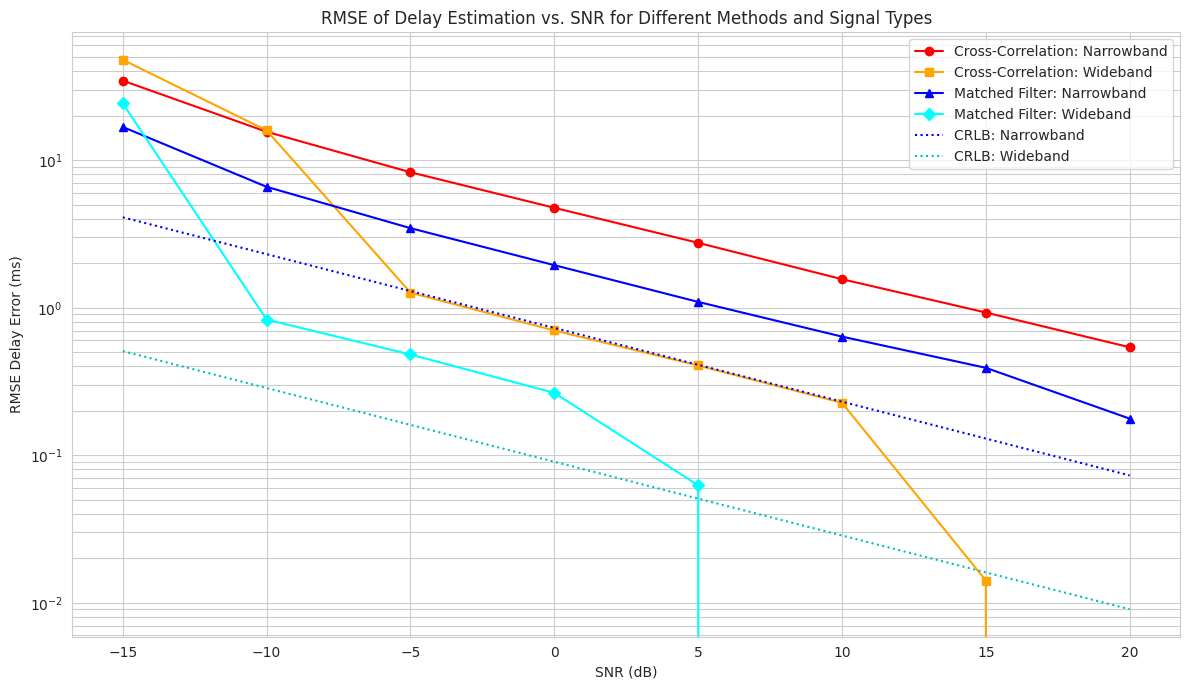

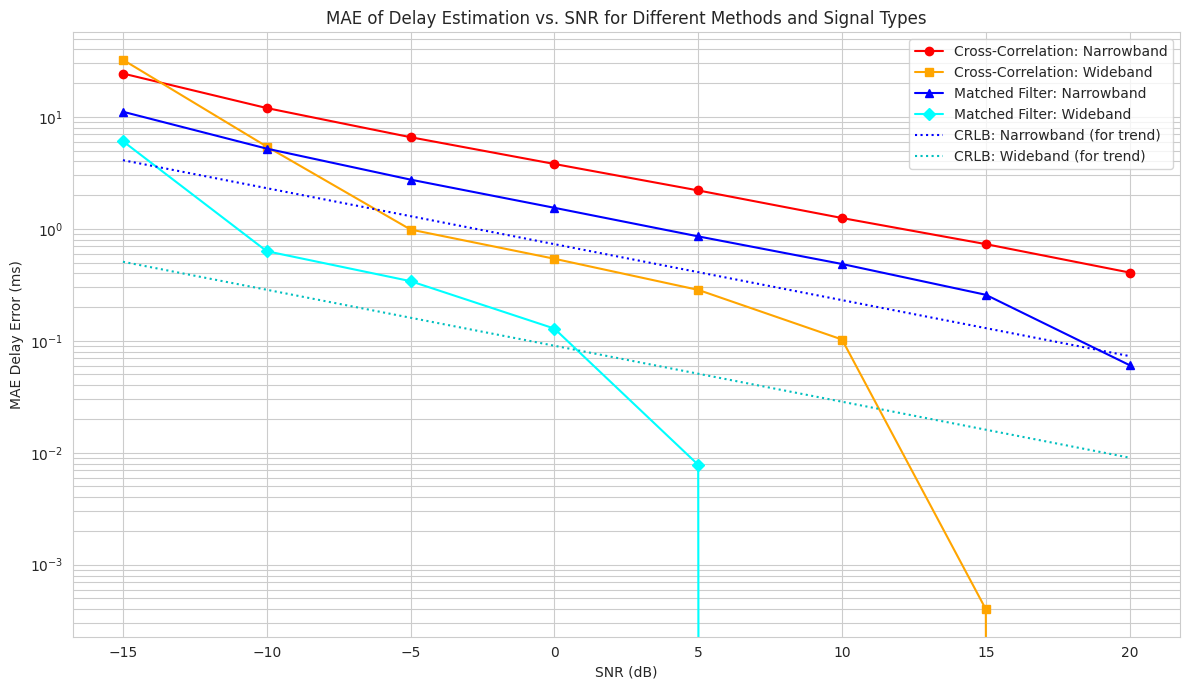

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting from the pivoted DataFrames
def extract_metric_for_plot(df_pivot, metric_name, signal_type):
    return df_pivot[(f'{metric_name} Delay Error (ms)', signal_type)].values

snrs = df_results_pivot_no_mf.index.values

# --- Plotting RMSE ---
rmse_no_mf_narrowband = extract_metric_for_plot(df_results_pivot_no_mf, 'RMSE', 'Narrowband')
rmse_no_mf_wideband = extract_metric_for_plot(df_results_pivot_no_mf, 'RMSE', 'Wideband')
rmse_mf_narrowband = extract_metric_for_plot(df_results_pivot_mf, 'RMSE', 'Narrowband')
rmse_mf_wideband = extract_metric_for_plot(df_results_pivot_mf, 'RMSE', 'Wideband')

plt.figure(figsize=(12, 7))
sns.set_style('whitegrid')

plt.plot(snrs, rmse_no_mf_narrowband, 'o-', color='red', label='Cross-Correlation: Narrowband')
plt.plot(snrs, rmse_no_mf_wideband, 's-', color='orange', label='Cross-Correlation: Wideband')
plt.plot(snrs, rmse_mf_narrowband, '^-', color='blue', label='Matched Filter: Narrowband')
plt.plot(snrs, rmse_mf_wideband, 'D-', color='cyan', label='Matched Filter: Wideband')

# Plot CRLB for RMSE
plt.plot(snrs, crlb_rmse_n_ms, 'b:', label='CRLB: Narrowband')
plt.plot(snrs, crlb_rmse_w_ms, 'c:', label='CRLB: Wideband')

plt.title('RMSE of Delay Estimation vs. SNR for Different Methods and Signal Types')
plt.xlabel('SNR (dB)')
plt.ylabel('RMSE Delay Error (ms)')
plt.yscale('log')
plt.legend()
plt.grid(True, which="both", ls="-")
plt.xticks(snrs)
plt.tight_layout()
plt.show()

# --- Plotting MAE ---
mae_no_mf_narrowband = extract_metric_for_plot(df_results_pivot_no_mf, 'MAE', 'Narrowband')
mae_no_mf_wideband = extract_metric_for_plot(df_results_pivot_no_mf, 'MAE', 'Wideband')
mae_mf_narrowband = extract_metric_for_plot(df_results_pivot_mf, 'MAE', 'Narrowband')
mae_mf_wideband = extract_metric_for_plot(df_results_pivot_mf, 'MAE', 'Wideband')

plt.figure(figsize=(12, 7))
sns.set_style('whitegrid')

plt.plot(snrs, mae_no_mf_narrowband, 'o-', color='red', label='Cross-Correlation: Narrowband')
plt.plot(snrs, mae_no_mf_wideband, 's-', color='orange', label='Cross-Correlation: Wideband')
plt.plot(snrs, mae_mf_narrowband, '^-', color='blue', label='Matched Filter: Narrowband')
plt.plot(snrs, mae_mf_wideband, 'D-', color='cyan', label='Matched Filter: Wideband')

# Plot CRLB for MAE (for trend observation)
plt.plot(snrs, crlb_rmse_n_ms, 'b:', label='CRLB: Narrowband (for trend)')
plt.plot(snrs, crlb_rmse_w_ms, 'c:', label='CRLB: Wideband (for trend)')

plt.title('MAE of Delay Estimation vs. SNR for Different Methods and Signal Types')
plt.xlabel('SNR (dB)')
plt.ylabel('MAE Delay Error (ms)')
plt.yscale('log')
plt.legend()
plt.grid(True, which="both", ls="-")
plt.xticks(snrs)
plt.tight_layout()
plt.show()

#### Brief Analysis of this MC result

As discussed before, our code is searching and calculating the error from the true time delay. So compared to our derived theory which assumed no time-delay, in higher SNRs we will find that our errors are log-linear and follow the idea that larger bandwidth signals have less error due to AWGN as expected from the CRLB analysis.

Comparing the RMSE against the CRLB variance, we can see that they are higher and follow a similar log-linear shape over SNR.

However, this observation will fail in lower SNRs. Analysis with Ai gives as to why this occurs, and I can walk through some of its reasoning and note the points where I am not convinced/confused myself.

The sharp cutdown in higher SNRs is due to not enough monte-carlo samples, so we can ignore that phenomenon.

#### Analysis of low-SNR (Incomplete - needs more review)

Portions of this section should go into the theory background, but due to time I'm putting it in analysis.

In short, our original formulation was incomplete, because we didn't account for looking at different possible delays when creating our estimator.
Also, because of the threshold function in our model, which is nonlinear, our errors should not be gaussian distributed, but rather results in a mixture so-called contaminated model, where in distribution is gaussian and out of distribution portion is a different distribution.

### AI Suggests the below, but I am not currently convinced:

You have $M$ possible delays: $\tau_1, \tau_2, ..., \tau_M$

Given that the true delay is $\tau_0$, we define the following:

Correlation at each delay:
- At true delay: $R(\tau_0) = E_s + N(\tau_0)$
- At wrong delay $\tau_i$$: $$R(\tau_i) = 0 + N(\tau_i)$

where $N(\tau_i)$ are correlated Gaussian random variables.

Our estimator: $\hat{\tau} = \arg\max_{\tau \in \{\tau_1, ..., \tau_M\}} R(\tau)$

Calculating the error probability, we find that the true delay has the error probability following the gaussian distribution, whereas the wrong delay has error probabiliy of:

When combining these using the total law of probability, our full distribution ends up becoming:

$$\boxed{p(\epsilon) = P_{correct} \cdot \mathcal{N}(0, \sigma_{CRB}^2) + P_{outlier} \cdot p_{outlier}(\epsilon)}$$

Given this information, after a certain SNR, the samples casted as outliers start to outweigh the error distribution, resulting in much worse errors. The

**The correlation between noise at two different delays:**

$$E[N(\tau_1) N(\tau_2)] = \sigma^2 \sum_n s[n-\tau_1] s[n-\tau_2]
= \sigma^2 R_{ss}(\tau_1 - \tau_2)$$

The noise at different delays is correlated according to the signal's autocorrelation function up to the autocorrelation function's width.

**Thin autocorrelation (large B):**
- less correlated noise over a window of time
- more independent windows - (This portion I am unconvinced)

**Thick autocorrelation  (small B):**
- more correlated noise over a window of time
- less independent windows - (This portion I am unconvinced)

In short, for later analysis, this somehow results in thin autocorrelations having more outliers.

#### References to look into:
Ziv-Zakai Lower Bound


## Case Study: GCC-PHAT

## TODO: DO THIS SECTION